
# RNN vs LSTM vs GRU

## Instructions

In this lab, you will build **three text classification models** from scratch:
- RNN
- LSTM
- GRU

---

### Objectives
By the end of this lab, you should be able to:

- Preprocess text data
- Build a vocabulary
- Encode and pad sequences
- Implement RNN, LSTM, and GRU in PyTorch
- Train and evaluate models 
- Compare architectures


In [1]:
import torch
import torch.nn as nn
import torch.optim as optim

from torch.utils.data import DataLoader, random_split
from datasets import load_dataset

from collections import Counter
import matplotlib.pyplot as plt
import numpy as np

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

c:\Users\Diogo\Desktop\MEI\4ºano\2ºsemestre\Aprendizagem Profunda\Trabalho\Modulo1\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Using device: cpu


c:\Users\Diogo\Desktop\MEI\4ºano\2ºsemestre\Aprendizagem Profunda\Trabalho\Modulo1\.venv\Lib\site-packages\torch\cuda\__init__.py:180: UserWarning: cudaGetDeviceCount() returned cudaErrorNotSupported, likely using older driver or on CPU machine (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\c10\cuda\CUDAFunctions.cpp:88.)
  return torch._C._cuda_getDeviceCount() > 0


In [2]:
label_map = {
    "Human": 0,
    "Anthropic": 1,
    "Google": 2,
    "OpenAI": 3,
    "Meta": 4
}

In [3]:
# data loading
dataset = load_dataset("csv", data_files="../dataset_final.csv", sep=";")

dataset = dataset["train"].train_test_split(test_size=0.2)

train_data = list(dataset["train"])
test_data = list(dataset["test"])

# remove exemples without labels
train_data = [x for x in train_data if x["Label"] is not None]
test_data = [x for x in test_data if x["Label"] is not None]

print("Train size:", len(train_data))
print("Test size:", len(test_data))

Train size: 5596
Test size: 1400


In [4]:
print(dataset["train"].features)
print(train_data[0])

{'ID': Value('large_string'), 'Text': Value('large_string'), 'Label': Value('large_string')}
{'ID': 'D1-4514', 'Text': 'Chloroplasts are the primary sites of photosynthesis in plant cells and algae, converting light energy into chemical energy in the form of glucose. These oval-shaped organelles contain their own circular DNA, ribosomes, and a double membrane, supporting their endosymbiotic origin. Internally, they feature stacks of thylakoids called grana, where the light-dependent reactions occur, capturing solar energy. The fluid-filled space surrounding the grana is called the stroma, where the light-independent reactions (Calvin cycle) take place, synthesizing sugars. Chlorophyll, the green pigment, is embedded in the thylakoid membranes, absorbing light. This remarkable organelle is fundamental for sustaining nearly all life on Earth by producing oxygen and organic compounds', 'Label': 'Meta'}


In [5]:
sum(1 for x in train_data if x["Label"] is None)

0

In [6]:
train_texts = [x["Text"] for x in train_data]
test_texts = [x["Text"] for x in test_data]

train_labels = [label_map[x["Label"].strip()] for x in train_data]
test_labels = [label_map[x["Label"].strip()] for x in test_data]


# Part 1 – Text Preprocessing

You must:

1. Write a `tokenize(text)` function.
2. Build a vocabulary using the training set only.
3. Keep only the top 10,000 most frequent words.
4. Add special tokens:
   - `<pad>`
   - `<unk>`
5. Explain in a markdown cell:
   - Why do we not build the vocabulary using the test set?


In [7]:
import re

def tokenize(text):
    text = str(text)
    text = text.lower()
    text = re.sub(r"<.*?>", "", text)
    text = re.sub(r"[^a-zA-Z]", " ", text)
    return text.split()

In [8]:
tokenize(train_data)

['id',
 'd',
 'text',
 'chloroplasts',
 'are',
 'the',
 'primary',
 'sites',
 'of',
 'photosynthesis',
 'in',
 'plant',
 'cells',
 'and',
 'algae',
 'converting',
 'light',
 'energy',
 'into',
 'chemical',
 'energy',
 'in',
 'the',
 'form',
 'of',
 'glucose',
 'these',
 'oval',
 'shaped',
 'organelles',
 'contain',
 'their',
 'own',
 'circular',
 'dna',
 'ribosomes',
 'and',
 'a',
 'double',
 'membrane',
 'supporting',
 'their',
 'endosymbiotic',
 'origin',
 'internally',
 'they',
 'feature',
 'stacks',
 'of',
 'thylakoids',
 'called',
 'grana',
 'where',
 'the',
 'light',
 'dependent',
 'reactions',
 'occur',
 'capturing',
 'solar',
 'energy',
 'the',
 'fluid',
 'filled',
 'space',
 'surrounding',
 'the',
 'grana',
 'is',
 'called',
 'the',
 'stroma',
 'where',
 'the',
 'light',
 'independent',
 'reactions',
 'calvin',
 'cycle',
 'take',
 'place',
 'synthesizing',
 'sugars',
 'chlorophyll',
 'the',
 'green',
 'pigment',
 'is',
 'embedded',
 'in',
 'the',
 'thylakoid',
 'membranes',
 '

In [9]:
from collections import Counter

def build_vocab(texts, max_words=10000):

    counter = Counter()

    for text in texts:

        if text is None:
            continue

        tokens = tokenize(text)
        counter.update(tokens)

    most_common = counter.most_common(max_words)

    vocab = {
        "<pad>": 0,
        "<unk>": 1
    }

    for word, _ in most_common:
        vocab[word] = len(vocab)

    return vocab

In [10]:
vocab = build_vocab(train_texts)


# Part 2 – Encoding and Padding

You must:

1. Create an `encode(text)` function.
2. Convert tokens into vocabulary indices.
3. Pad or truncate sequences to a fixed length (e.g., 25).
4. Create a custom `collate()` function.
5. Create train, validation, and test DataLoaders.

Explain:
- Why is padding necessary?
- Why should validation and test loaders not shuffle?


In [11]:
def encode(vocab, text, max_len=25):
    tokens = tokenize(text)

    ids = [vocab.get(token, vocab["<unk>"]) for token in tokens]

    if len(ids) < max_len:
        ids += [vocab["<pad>"]] * (max_len - len(ids))
    else:
        ids = ids[:max_len]

    return ids

In [12]:
def one_hot_encode(vocab, token):
    vector = np.zeros(len(vocab))
    
    token_index = vocab.get(token, vocab["<unk>"])
    vector[token_index] = 1
    
    return vector

In [13]:
train_loader = DataLoader(
    dataset["train"],
    batch_size=32,
    shuffle=True
)

test_loader = DataLoader(
    dataset["test"],
    batch_size=32,
    shuffle=False
)


# Part 3 – Model Implementation

Create a class called `Model` that:

- Uses an Embedding layer
- Supports:
  - RNN
  - LSTM
  - GRU
  - Transformers
- Uses multiple layers
- Applies dropout
- Outputs class logits

Your model must accept:
- model_type
- vocab_size
- embed_dim
- hidden_dim
- num_layers

Explain:
- The internal difference between RNN, LSTM, and GRU.


In [14]:
class Model(nn.Module):
    def __init__(self, model_type, vocab_size, embed_dim, hidden_dim, num_layers, dropout=0.2):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.dropout = nn.Dropout(dropout)

        if model_type == "RNN":
            self.rnn = nn.RNN(embed_dim, hidden_dim, num_layers, batch_first=True)
        elif model_type == "LSTM":
            self.rnn = nn.LSTM(embed_dim, hidden_dim, num_layers, batch_first=True)
        else:
            self.rnn = nn.GRU(embed_dim, hidden_dim, num_layers, batch_first=True)

        self.fc = nn.Linear(hidden_dim, 4)

        def forward(self, x):
            x = self.embedding(x)
            x = self.drpout(x)
            out, h = self.rnn(x)
            if isinstance(h, tuple):
                h = h[0]
                return self.fc(h[-1])


# Part 4 – Training Loop

Implement:

- A full training loop
- Validation loop
- Accuracy computation
- Loss tracking per epoch

Train for 10-50 epochs.

Store:
- train_loss
- val_loss
- train_accuracy
- val_accuracy

Explain:
- Why do we use `model.train()` and `model.eval()`?


In [15]:
def train(model, train_loader, val_loader, criterion, epochs = 10, lr = 0.001, verbose = True):
    ## verbose - print losses and accuracies per epoch
    
    train_accs = []
    val_accs = []
    train_losses = []
    val_losses = []
    
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.to(device)
    
    for epoch in range(epochs): 
        model.train()
        for x, y in train_loader:
            optimizer.zero_grad()
            outputs = model(x)
            loss = criterion(outputs, y)
            loss.backward()
            optimizer.step()

        train_loss, train_acc = evaluate(model, train_loader, criterion)
        val_loss, val_acc = evaluate(model, val_loader, criterion)
        
        train_accs.append(train_acc)
        train_losses.append(train_loss)
        val_accs.append(val_acc)
        val_losses.append(val_loss)

        if verbose: 
            print(f"Epoch {epoch+1}")
            print(f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f}")
            print(f"Val   Loss: {val_loss:.4f}, Val   Acc: {val_acc:.4f}")
    
    return train_accs, val_accs, train_losses, val_losses


# Part 5 – Model Comparison

Train:
- RNN
- LSTM
- GRU
- Transformers

Track validation accuracy and determine:
- Which performs best?
- Why?

Plot:
- Loss curves
- Accuracy curves

Explain signs of overfitting.


In [16]:
def evaluate(model, loader, criterion):
    model.eval()
    total_loss = 0
    correct = 0
    total = 0

    with torch.no_grad():
        for x, y in loader:
            outputs = model(x)
            loss = criterion(outputs, y)
            total_loss += loss.item()

            preds = torch.argmax(outputs, dim=1)
            correct += (preds == y).sum().item()
            total += y.size(0)

    return total_loss / len(loader), correct / total

In [17]:
def plot_values(list_values, list_labels  = ["Train", "Validation"], ylabel = "Accuracy", title = None):
    plt.figure()
    for i in range(len(list_values)):
        plt.plot(list_values[i], label = list_labels[i])
    plt.xlabel("Epoch")
    plt.ylabel(ylabel)
    plt.legend()
    if title is not None: plt.title()
    plt.show()

In [18]:
def load_dataset_embed(filespath, max_words, max_len=100, batch_size=32):

    dataset = load_dataset("csv", data_files=filespath,sep=";")

    dataset = dataset["train"].train_test_split(test_size=0.2)

    train_data = dataset["train"]
    test_data = dataset["test"]

    train_texts = [x["Text"] for x in train_data]
    train_labels = [x["Label"] for x in train_data]

    test_texts = [x["Text"] for x in test_data]
    test_labels = [x["Label"] for x in test_data]

    vocab = build_vocab(train_texts, max_words)

    def collate(batch):
        texts = [x["Text"] for x in batch if x["Label"] is not None]
        labels = [
            label_map[x["Label"].strip()]
            for x in batch
            if x["Label"] is not None
        ]
    
        encoded = [encode(vocab, t, max_len) for t in texts]
    
        x = torch.tensor(encoded, dtype=torch.long)
        y = torch.tensor(labels, dtype=torch.long)
        return x.to(device), y.to(device)

    train_loader = DataLoader(train_data, batch_size=batch_size, shuffle=True, collate_fn=collate)

    val_loader = DataLoader(test_data, batch_size=batch_size, shuffle=False, collate_fn=collate)

    test_loader = DataLoader(test_data, batch_size=batch_size, shuffle=False, collate_fn=collate)

    return train_loader, val_loader, test_loader, vocab

In [19]:
class RNNClassifier(nn.Module):

    def __init__(self, vocab_size, embed_dim, hidden_dim, num_layers=1):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.rnn = nn.RNN(
            input_size=embed_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True
        )
        self.fc = nn.Linear(hidden_dim, 5)

    def forward(self, x):
        embedded = self.embedding(x)
        output, hidden = self.rnn(embedded)
        last_hidden = hidden[-1]
        out = self.fc(last_hidden)
        return out

In [20]:
class LSTMClassifier(nn.Module):

    def __init__(self, vocab_size, embed_dim, hidden_dim, num_layers=1, dropout=0.0, bidirectional=False, num_classes=5):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)

        self.lstm = nn.LSTM(
            input_size=embed_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            bidirectional=bidirectional,
            dropout=dropout if num_layers > 1 else 0.0
        )

        self.dropout = nn.Dropout(dropout)
        direction_factor = 2 if bidirectional else 1
        self.fc = nn.Linear(hidden_dim * direction_factor, num_classes)

    def forward(self, x):
        # x: (batch_size, seq_len)
        embedded = self.embedding(x)     # (B, L, E)
        output, (hidden, cell) = self.lstm(embedded)

        if self.lstm.bidirectional:
            forward_hidden = hidden[-2]
            backward_hidden = hidden[-1]
            last_hidden = torch.cat((forward_hidden, backward_hidden), dim=1)
        else:
            last_hidden = hidden[-1]

        last_hidden = self.dropout(last_hidden)

        out = self.fc(last_hidden)

        return out   # (B, num_classes)

In [21]:
class GRUClassifier(nn.Module):

    def __init__(self, vocab_size, embed_dim, hidden_dim, num_layers=1, dropout=0.0, bidirectional=False, num_classes=5):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)

        self.gru = nn.GRU(
            input_size=embed_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            bidirectional=bidirectional,
            dropout=dropout if num_layers > 1 else 0.0
        )

        self.dropout = nn.Dropout(dropout)
        direction_factor = 2 if bidirectional else 1
        self.fc = nn.Linear(hidden_dim * direction_factor, num_classes)

    def forward(self, x):
        # x: (batch_size, seq_len)
        embedded = self.embedding(x)
        output, hidden = self.gru(embedded)

        if self.gru.bidirectional:
            forward_hidden = hidden[-2]
            backward_hidden = hidden[-1]
            last_hidden = torch.cat((forward_hidden, backward_hidden), dim=1)
        else:
            last_hidden = hidden[-1]
        last_hidden = self.dropout(last_hidden)
        out = self.fc(last_hidden)
        return out   # (B, num_classes)

## Transformer architecture

In [22]:
import math

# ─────────────────────────────────────────────
# Building blocks
# ─────────────────────────────────────────────

class PositionalEncoding(nn.Module):
    """
    Sinusoidal positional encoding (same formula as the original
    "Attention Is All You Need" paper).

    Adds position information to the token embeddings so the model
    knows the order of words — Transformers have no built-in notion
    of sequence order unlike RNNs.
    """

    def __init__(self, embed_dim, max_len=512):
        super().__init__()

        pe = torch.zeros(max_len, embed_dim)

        for pos in range(max_len):
            for i in range(0, embed_dim, 2):
                pe[pos, i]     = math.sin(pos / (10000 ** (i / embed_dim)))
                pe[pos, i + 1] = math.cos(pos / (10000 ** (i / embed_dim)))

        # Shape: (1, max_len, embed_dim) — the leading 1 broadcasts over batches
        self.register_buffer("pe", pe.unsqueeze(0))

    def forward(self, x):
        # x: (batch, seq_len, embed_dim)
        return x + self.pe[:, :x.size(1)]


class SelfAttention(nn.Module):
    """
    Single-head scaled dot-product attention.

    Q, K, V are linear projections of the same input x (self-attention).
    Each token can directly attend to every other token in the sequence,
    which is the key advantage over RNNs where information must travel
    step-by-step.
    """

    def __init__(self, embed_dim):
        super().__init__()
        self.q = nn.Linear(embed_dim, embed_dim)
        self.k = nn.Linear(embed_dim, embed_dim)
        self.v = nn.Linear(embed_dim, embed_dim)

    def forward(self, x):
        Q = self.q(x)   # (B, L, D)
        K = self.k(x)   # (B, L, D)
        V = self.v(x)   # (B, L, D)

        # Scale to prevent vanishing gradients in softmax
        scale  = math.sqrt(Q.size(-1))
        scores = torch.matmul(Q, K.transpose(-2, -1)) / scale   # (B, L, L)
        weights = torch.softmax(scores, dim=-1)

        return torch.matmul(weights, V)   # (B, L, D)


class MultiHeadAttention(nn.Module):
    """
    Multiple independent attention heads run in parallel.

    Each head learns to attend to different aspects of the text
    (e.g. one head might focus on syntactic structure, another on
    semantic similarity). Outputs are concatenated and projected back.
    """

    def __init__(self, embed_dim, num_heads):
        super().__init__()
        self.heads  = nn.ModuleList(
            [SelfAttention(embed_dim) for _ in range(num_heads)]
        )
        # Project the concatenated head outputs back to embed_dim
        self.linear = nn.Linear(embed_dim * num_heads, embed_dim)

    def forward(self, x):
        head_outputs = [head(x) for head in self.heads]   # num_heads × (B, L, D)
        concat = torch.cat(head_outputs, dim=-1)           # (B, L, D * num_heads)
        return self.linear(concat)                         # (B, L, D)


class TransformerBlock(nn.Module):
    """
    One encoder layer:
      1. Multi-head self-attention
      2. Residual connection + LayerNorm
      3. Position-wise feed-forward network
      4. Residual connection + LayerNorm

    Residual connections let gradients flow through deep stacks;
    LayerNorm stabilises training.
    """

    def __init__(self, embed_dim, num_heads, ff_dim, dropout=0.1):
        super().__init__()
        self.attn  = MultiHeadAttention(embed_dim, num_heads)
        self.norm1 = nn.LayerNorm(embed_dim)
        self.ff    = nn.Sequential(
            nn.Linear(embed_dim, ff_dim),
            nn.ReLU(),
            nn.Linear(ff_dim, embed_dim),
        )
        self.norm2   = nn.LayerNorm(embed_dim)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        # Attention sub-layer
        attn_out = self.attn(x)
        x = self.norm1(x + self.dropout(attn_out))

        # Feed-forward sub-layer
        ff_out = self.ff(x)
        x = self.norm2(x + self.dropout(ff_out))

        return x


# ─────────────────────────────────────────────
# Full classifier
# ─────────────────────────────────────────────

class TransformerClassifier(nn.Module):
    """
    Transformer encoder for text classification.

    Architecture:
      token ids
        → Embedding
        → + Positional Encoding
        → N × TransformerBlock
        → mean-pool over sequence
        → Linear classifier

    Mean-pooling is used instead of taking only the first/last token
    so that every position contributes equally to the final prediction.

    Args:
        vocab_size  : size of the vocabulary (including <pad> and <unk>)
        embed_dim   : token embedding dimension
        num_heads   : number of attention heads per block
        ff_dim      : inner dimension of the feed-forward sublayer
        num_layers  : number of stacked TransformerBlocks
        num_classes : number of output classes (5 for this project)
        max_len     : maximum sequence length (must match encode() max_len)
        dropout     : dropout probability applied inside each block
    """

    def __init__(
        self,
        vocab_size,
        embed_dim   = 128,
        num_heads   = 4,
        ff_dim      = 256,
        num_layers  = 2,
        num_classes = 5,
        max_len     = 120,
        dropout     = 0.3,
    ):
        super().__init__()

        self.embedding     = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.pos_encoding  = PositionalEncoding(embed_dim, max_len)
        self.dropout       = nn.Dropout(dropout)

        self.layers = nn.ModuleList([
            TransformerBlock(embed_dim, num_heads, ff_dim, dropout)
            for _ in range(num_layers)
        ])

        self.classifier = nn.Linear(embed_dim, num_classes)

    def forward(self, x):
        # x: (batch_size, seq_len)

        out = self.embedding(x)        # (B, L, D)
        out = self.pos_encoding(out)   # (B, L, D)
        out = self.dropout(out)

        for layer in self.layers:
            out = layer(out)           # (B, L, D)

        # Mean-pool over the sequence dimension
        out = out.mean(dim=1)          # (B, D)

        return self.classifier(out)    # (B, num_classes)

In [27]:
def test_rnn():
    filespath = "../dataset_final.csv"
    max_words = 20000
    max_len = 100
    embed_dim = 200
    train_loader, val_loader, test_loader, vocab_local = load_dataset_embed(filespath, max_words, max_len = max_len)
    vocab_size_real = len(vocab_local)
    model = RNNClassifier(vocab_size_real,embed_dim, hidden_dim=128, num_layers=1)
    criterion = nn.CrossEntropyLoss()
    train_accs, val_accs, train_losses, val_losses = train(model, train_loader, val_loader, criterion, epochs = 10)

    plot_values([train_accs, val_accs])
    plot_values([train_losses, val_losses], ylabel = "Loss")
    
    _, test_acc = evaluate(model, test_loader, criterion)
    print(f"Test Accuracy: {test_acc:.4f}")
    confusion_matrix_eval(model, test_loader)
    return model, vocab_local

def test_lstm():
    filespath = "../dataset_final.csv"
    max_words = 20000
    max_len = 100 ## do not increase
    embed_dim = 200
    train_loader, val_loader, test_loader, vocab_local = load_dataset_embed(filespath, max_words, max_len = max_len)
    vocab_size_real = len(vocab_local)
    model = LSTMClassifier(vocab_size_real,embed_dim, hidden_dim=128, num_layers=2, bidirectional = True, dropout = 0.5)
    criterion = nn.CrossEntropyLoss()
    train_accs, val_accs, train_losses, val_losses = train(model, train_loader, val_loader, criterion, epochs = 10) #, lr = 0.0001)

    plot_values([train_accs, val_accs])
    plot_values([train_losses, val_losses], ylabel = "Loss")
    
    _, test_acc = evaluate(model, test_loader, criterion)
    print(f"Test Accuracy: {test_acc:.4f}")
    confusion_matrix_eval(model, test_loader)
    return model, vocab_local

def test_gru():
    filespath = "../dataset_final.csv"
    max_words = 20000
    max_len = 100 ## do not increase
    embed_dim = 200
    train_loader, val_loader, test_loader, vocab_local = load_dataset_embed(filespath, max_words, max_len = max_len)
    vocab_size_real = len(vocab_local)
    model = GRUClassifier(vocab_size_real,embed_dim, hidden_dim=128, num_layers=1, bidirectional = True, dropout = 0.3)
    
    criterion = nn.CrossEntropyLoss()
    
    train_accs, val_accs, train_losses, val_losses = train(model, train_loader, val_loader, criterion, epochs = 5) #, lr = 0.0001)
    
    plot_values([train_accs, val_accs])
    plot_values([train_losses, val_losses], ylabel = "Loss")
    
    _, test_acc = evaluate(model, test_loader, criterion)
    print(f"Test Accuracy: {test_acc:.4f}")
    confusion_matrix_eval(model, test_loader)
    return model, vocab_local

def test_transformer():
    filespath  = "../dataset_master_final.csv"
    max_words  = 20000
    max_len    = 100
    embed_dim  = 128
    num_heads  = 4
    ff_dim     = 256
    num_layers = 2
    dropout    = 0.4     
 
    train_loader, val_loader, test_loader, vocab_local = load_dataset_embed(
        filespath, max_words, max_len=max_len
    )
 
    vocab_size = len(vocab_local)
 
    model = TransformerClassifier(
        vocab_size  = vocab_size,
        embed_dim   = embed_dim,
        num_heads   = num_heads,
        ff_dim      = ff_dim,
        num_layers  = num_layers,
        num_classes = 5,
        max_len     = max_len,
        dropout     = dropout,
    ).to(device)
 

    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
 
    # ── Early stopping config ─────────────────────────────────────────────
    num_epochs    = 20          # high ceiling — early stopping will cut it short
    patience      = 5           # stop if val_acc doesn't improve for 4 epochs
    best_val_acc  = 0.0
    no_improve    = 0
    best_path     = "best_transformer.pt"
    # ─────────────────────────────────────────────────────────────────────
 
    train_accs, val_accs, train_losses, val_losses = [], [], [], []
 
    for epoch in range(num_epochs):
        # ── Training ──────────────────────────────────────────────────────
        model.train()
        running_loss, correct, total = 0.0, 0, 0
 
        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)
            optimizer.zero_grad()
            logits = model(xb)
            loss   = criterion(logits, yb)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
 
            running_loss += loss.item() * xb.size(0)
            correct      += (logits.argmax(1) == yb).sum().item()
            total        += yb.size(0)
 
        train_loss = running_loss / total
        train_acc  = correct / total
 
        # ── Validation ────────────────────────────────────────────────────
        val_loss, val_acc = evaluate(model, val_loader, criterion)
 
        train_losses.append(train_loss)
        val_losses.append(val_loss)
        train_accs.append(train_acc)
        val_accs.append(val_acc)
 
        print(f"Epoch {epoch+1:>2} | "
              f"train_loss={train_loss:.4f}  train_acc={train_acc:.4f} | "
              f"val_loss={val_loss:.4f}  val_acc={val_acc:.4f}", end="")
 
        # ── Early stopping check ──────────────────────────────────────────
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            no_improve   = 0
            torch.save(model.state_dict(), best_path)
            print("  ← saved")
        else:
            no_improve += 1
            print(f"  (no improve {no_improve}/{patience})")
            if no_improve >= patience:
                print(f"\nEarly stopping at epoch {epoch+1}. "
                      f"Best val_acc={best_val_acc:.4f}")
                break
 
    # ── Restore best checkpoint ───────────────────────────────────────────
    model.load_state_dict(torch.load(best_path))
    print(f"\nRestored best checkpoint ({best_path}).")
 
    # ── Plots ─────────────────────────────────────────────────────────────
    plot_values([train_accs,   val_accs],   ylabel="Accuracy")
    plot_values([train_losses, val_losses], ylabel="Loss")
 
    # ── Final test evaluation ─────────────────────────────────────────────
    _, test_acc = evaluate(model, test_loader, criterion)
    print(f"Test Accuracy: {test_acc:.4f}")
    confusion_matrix_eval(model, test_loader)
 
    return model, vocab_local


# Part 6 – Final Evaluation

Using the best model:

1. Evaluate on the test set.
2. Compute test accuracy.
3. Plot a confusion matrix.

Explain:
- Which classes are most confused?
- Why might that happen?


In [24]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

def confusion_matrix_eval(model, loader):

    model.eval()

    all_preds = []
    all_labels = []

    with torch.no_grad():
        for x, y in loader:

            outputs = model(x)

            preds = torch.argmax(outputs, dim=1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(y.cpu().numpy())

    cm = confusion_matrix(all_labels, all_preds)

    disp = ConfusionMatrixDisplay(cm)
    disp.plot()

Epoch  1 | train_loss=0.6522  train_acc=0.7378 | val_loss=0.4079  val_acc=0.8432  ← saved
Epoch  2 | train_loss=0.3985  train_acc=0.8490 | val_loss=0.3177  val_acc=0.8831  ← saved
Epoch  3 | train_loss=0.3317  train_acc=0.8768 | val_loss=0.2927  val_acc=0.8967  ← saved
Epoch  4 | train_loss=0.2846  train_acc=0.8923 | val_loss=0.3471  val_acc=0.8887  (no improve 1/5)
Epoch  5 | train_loss=0.2624  train_acc=0.9033 | val_loss=0.2788  val_acc=0.9078  ← saved
Epoch  6 | train_loss=0.2435  train_acc=0.9096 | val_loss=0.2488  val_acc=0.9175  ← saved
Epoch  7 | train_loss=0.2243  train_acc=0.9168 | val_loss=0.2317  val_acc=0.9226  ← saved
Epoch  8 | train_loss=0.2126  train_acc=0.9226 | val_loss=0.2144  val_acc=0.9315  ← saved
Epoch  9 | train_loss=0.2042  train_acc=0.9254 | val_loss=0.2118  val_acc=0.9286  (no improve 1/5)
Epoch 10 | train_loss=0.1957  train_acc=0.9288 | val_loss=0.2379  val_acc=0.9200  (no improve 2/5)
Epoch 11 | train_loss=0.1846  train_acc=0.9331 | val_loss=0.2412  val_acc

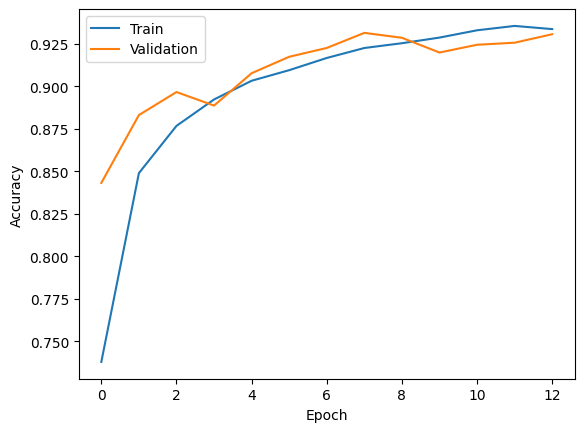

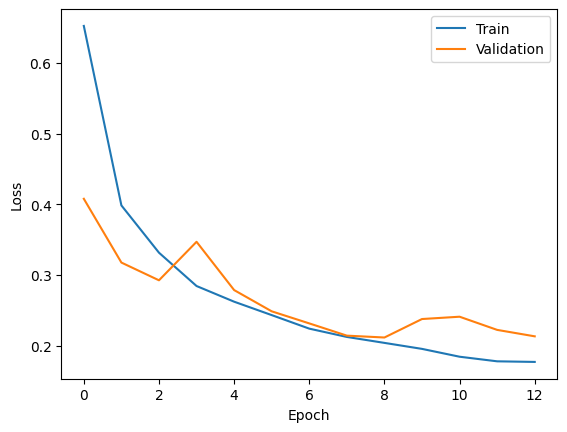

Test Accuracy: 0.9315


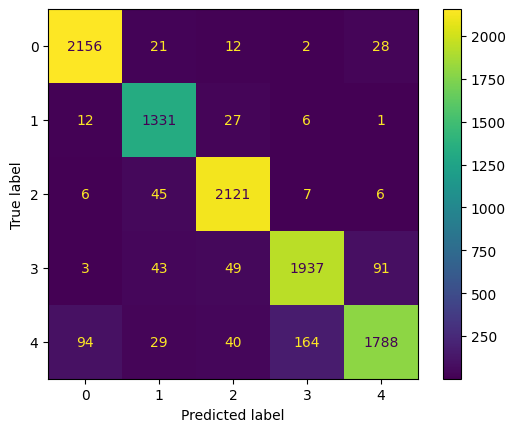

In [28]:
#model_rnn, vocab_do_treino = test_rnn() # val_acc = ~0.50
#model_lstm, vocab_do_treino = test_lstm() # val_acc = 0.71
# model_gru, vocab_do_treino = test_gru() # val_acc = 0.74
model_transformer, vocab_do_treino = test_transformer()


# Part 7 - submission file


In [179]:
def fill_csv(model, input_file, output_file, vocab, max_len=100):
    dataset = load_dataset("csv", data_files=input_file, sep=";")["train"]

    inverse_label_map = {v: k for k, v in label_map.items()}

    model.eval()
    predictions = []

    with torch.no_grad():
        for text in dataset["Text"]:
            seq = encode(vocab, str(text), max_len)
            x   = torch.tensor(seq).unsqueeze(0).to(device)
            pred_idx   = torch.argmax(model(x), dim=1).item()
            predictions.append(inverse_label_map[pred_idx])

    # Write output: only ID and Label, ; separated, original order preserved
    with open(output_file, "w", encoding="utf-8") as f:
        f.write("ID;Label\n")
        for row_id, label in zip(dataset["ID"], predictions):
            f.write(f"{row_id};{label}\n")

    print(f"Saved {len(predictions)} predictions → {output_file}")

In [180]:
fill_csv(model_transformer, "../subm2.csv", "../subm2-g6-MEI-B.csv", vocab_do_treino, max_len = 100)

Generating train split: 150 examples [00:00, 16822.97 examples/s]


Saved 150 predictions → ../subm2-g6-MEI-B.csv


🛡️ A extrair IDs e Labels à prova de erros...

🎯 Accuracy Final: 0.2000 (20 certos em 100 textos)

🔍 Relatório Detalhado por Classe:
                                                                                                                                                                                                                                                                                                                                                                                                                                                           precision    recall  f1-score   support

                                                                                                                                                                                                                                                                                                                                                                                               

c:\Users\Diogo\Desktop\MEI\4ºano\2ºsemestre\Aprendizagem Profunda\Trabalho\Modulo1\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Diogo\Desktop\MEI\4ºano\2ºsemestre\Aprendizagem Profunda\Trabalho\Modulo1\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Diogo\Desktop\MEI\4ºano\2ºsemestre\Aprendizagem Profunda\Trabalho\Modulo1\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true sa

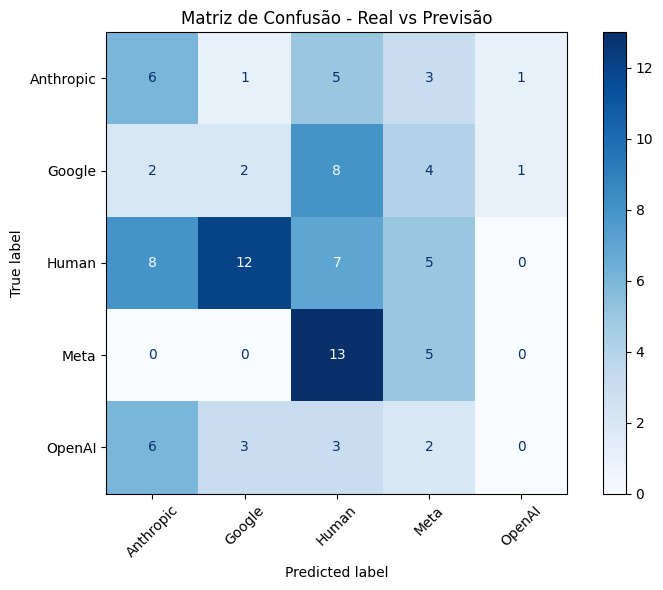

In [175]:
from sklearn.metrics import accuracy_score, classification_report

ficheiro_previsoes = '../subm1_predicted_test.csv' 
ficheiro_respostas = '../subm1_labels_revealed.csv'

print("🛡️ A extrair IDs e Labels à prova de erros...\n")

try:
    # 1. Leitura "Blindada" do ficheiro de previsões (ignora o texto problemático)
    ids_pred = []
    labels_pred = []
    
    with open(ficheiro_previsoes, 'r', encoding='utf-8') as f:
        linhas = f.readlines()
        # Ignorar a primeira linha (cabeçalho) e processar o resto
        for linha in linhas[1:]:
            linha = linha.strip()
            if not linha: continue
            
            partes = linha.split(';')
            ids_pred.append(partes[0].strip())   # O ID é sempre a primeira coisa
            labels_pred.append(partes[-1].strip()) # A Label é sempre a última
            
    df_pred = pd.DataFrame({'ID': ids_pred, 'Label': labels_pred})

    # 2. Carregar as respostas verdadeiras (este ficheiro do prof costuma estar limpo)
    df_real = pd.read_csv(ficheiro_respostas, sep=';')
    if 'label' in df_real.columns: df_real.rename(columns={'label': 'Label'}, inplace=True)

    # 3. Juntar os dois dataframes através do 'ID'
    df_comparacao = pd.merge(df_real[['ID', 'Label']], df_pred[['ID', 'Label']], 
                             on='ID', suffixes=('_real', '_pred'))
    
    y_true = df_comparacao['Label_real']
    y_pred = df_comparacao['Label_pred']
    
    # 4. Calcular Métricas
    accuracy = accuracy_score(y_true, y_pred)
    certos = sum(y_true == y_pred)
    total = len(y_true)
    
    print(f"🎯 Accuracy Final: {accuracy:.4f} ({certos} certos em {total} textos)\n")
    
    print("🔍 Relatório Detalhado por Classe:")
    print(classification_report(y_true, y_pred))
    
    # 5. Matriz de Confusão
    labels_unicas = sorted(list(y_true.unique()))
    cm = confusion_matrix(y_true, y_pred, labels=labels_unicas)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels_unicas)
    
    fig, ax = plt.subplots(figsize=(8, 6))
    disp.plot(cmap=plt.cm.Blues, ax=ax, xticks_rotation=45)
    plt.title("Matriz de Confusão - Real vs Previsão")
    plt.tight_layout()
    plt.show()

except Exception as e:
    print(f"❌ Ocorreu um erro: {e}")